# 范式B：用 shallowPLRNN 重构 Lorenz63 动力系统

本教程演示 NeuralRNN 的**动力学重构**完整流程，复现 CNS2023 tutorial 的核心结果：

1. 载入 Lorenz63 数据（`load_dataset`）
2. 用 `AutoModel` 构造 shallowPLRNN，配 `TeacherForcingObjective`(GTF) 训练
3. 自由运行生成轨迹，计算重构指标 **D_stsp / D_H / λ_max**
4. 用 `find_fixed_points` **解析**求不动点并判稳定性
5. `save_pretrained` / `from_pretrained` 存读

> 需要：`pip install -e .`（核心依赖）。可视化需 `pip install 'neuralrnn[viz]'`。

## 0. 准备

In [4]:
import torch, numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('../src')
from neuralrnn import AutoConfig, AutoModel, Trainer, TrainingArguments
from neuralrnn import TeacherForcingObjective, load_dataset
torch.manual_seed(42); np.random.seed(42)

## 1. 数据：Lorenz63
`load_dataset` 会按 `data/registry.py` 的登记自动下载/缓存 CNS-2023 数据并切成子序列批。
（无网环境请先把数据手动放到缓存目录，见 `data/download.py` 的提示。）

In [5]:
ds = load_dataset('lorenz63', sequence_length=200, batch_size=16, normalize=True)
print('观测维 N =', ds.N, '| 训练长度 T =', ds.T)
batch = ds.sample_batch()
print({k: (v.shape if torch.is_tensor(v) else v) for k, v in batch.items()})

[neuralrnn] 下载 https://github.com/DurstewitzLab/CNS-2023/raw/main/lorenz-datasets.zip
          -> C:\Users\heiheihei\.cache\neuralrnn\datasets\lorenz-datasets\lorenz-datasets.zip
观测维 N = 3 | 训练长度 T = 100000
{'inputs': torch.Size([16, 200, 3]), 'targets': torch.Size([16, 200, 3]), 'external_inputs': None}


## 2. 模型 + 目标 + 训练
shallowPLRNN：潜维 $M=N=3$（identity 读出），隐层 $L=50$，自治（无外部输入）。
GTF 强度 $\alpha=0.1$ 做稀疏强制以稳定混沌系统训练。

In [22]:
cfg = AutoConfig.for_model('shallow_plrnn',
                           input_dim=0, latent_dim=ds.N, output_dim=ds.N,
                           hidden_dim=50, autonomous=True)
model = AutoModel.from_config(cfg)
print(model.__class__.__name__, '| #params =', model.num_parameters())

objective = TeacherForcingObjective(alpha=0.1)
args = TrainingArguments(max_steps=2000, learning_rate=1e-3,
                         grad_clip_norm=10.0, log_every=200)
Trainer(model, ds, objective, args).train()

ShallowPLRNNModel | #params = 356
[train] step=0  loss=0.6668  alpha=0.1000
[train] step=200  loss=0.0164  alpha=0.1000
[train] step=400  loss=0.0082  alpha=0.1000
[train] step=600  loss=0.0087  alpha=0.1000
[train] step=800  loss=0.0062  alpha=0.1000
[train] step=1000  loss=0.0053  alpha=0.1000
[train] step=1200  loss=0.0048  alpha=0.1000
[train] step=1400  loss=0.0040  alpha=0.1000
[train] step=1600  loss=0.0038  alpha=0.1000
[train] step=1800  loss=0.0036  alpha=0.1000


[{'step': 0, 'loss': 0.6668369770050049, 'alpha': 0.1},
 {'step': 1, 'loss': 0.6551681756973267, 'alpha': 0.1},
 {'step': 2, 'loss': 0.643430233001709, 'alpha': 0.1},
 {'step': 3, 'loss': 0.6654139161109924, 'alpha': 0.1},
 {'step': 4, 'loss': 0.634333074092865, 'alpha': 0.1},
 {'step': 5, 'loss': 0.6268016695976257, 'alpha': 0.1},
 {'step': 6, 'loss': 0.5959175825119019, 'alpha': 0.1},
 {'step': 7, 'loss': 0.5640571713447571, 'alpha': 0.1},
 {'step': 8, 'loss': 0.5272839069366455, 'alpha': 0.1},
 {'step': 9, 'loss': 0.5400200486183167, 'alpha': 0.1},
 {'step': 10, 'loss': 0.5050818920135498, 'alpha': 0.1},
 {'step': 11, 'loss': 0.4799945056438446, 'alpha': 0.1},
 {'step': 12, 'loss': 0.4672389328479767, 'alpha': 0.1},
 {'step': 13, 'loss': 0.4760493338108063, 'alpha': 0.1},
 {'step': 14, 'loss': 0.44455718994140625, 'alpha': 0.1},
 {'step': 15, 'loss': 0.38304585218429565, 'alpha': 0.1},
 {'step': 16, 'loss': 0.44459599256515503, 'alpha': 0.1},
 {'step': 17, 'loss': 0.4129085540771484

## 3. 自由运行 + 重构指标
从一个初值自由 rollout（无教师强制），与真实测试轨迹比较 D_stsp / D_H，并估 λ_max。

In [26]:
gen.shape, true.shape

((5001, 3), (100000, 3))

In [27]:
from neuralrnn.analysis import (state_space_divergence, power_spectrum_error,
                                max_lyapunov_exponent)

z0 = torch.zeros(1, ds.N)
true = ds.test.numpy() if ds.test is not None else ds.X.numpy()
gen = model.generate(z0, n_steps=true.shape[0])[0].numpy()          # (T+1, N)

print('D_stsp =', round(state_space_divergence(gen, true), 4))
print('D_H    =', round(power_spectrum_error(true, gen, smoothing=20.0), 4))
lam = max_lyapunov_exponent(model, torch.tensor(gen[-1], dtype=torch.float32),
                            T=2000, T_trans=500)
print('lambda_max =', round(lam, 3), '(Lorenz63 真值 ~0.9)')

D_stsp = 2.2465
D_H    = 0.0701
lambda_max = 0.011 (Lorenz63 真值 ~0.9)


In [ ]:
fig = plt.figure(figsize=(8, 4))
ax1 = fig.add_subplot(121, projection='3d'); ax1.plot(*true[:2000].T, lw=0.4); ax1.set_title('true')
ax2 = fig.add_subplot(122, projection='3d'); ax2.plot(*gen[:2000].T, lw=0.4); ax2.set_title('reconstruction')
plt.tight_layout(); plt.show()

## 4. 解析不动点 / 稳定性
PLRNN 支持解析后端，`find_fixed_points` 会自动走 `scy_fi` 精确求解。

找到 4 个不动点
  z*= [-1.154 -0.997  0.579] | 稳定: False | max|eig|= 2.409
  z*= [-1.109  1.033  5.083] | 稳定: False | max|eig|= 2.369
  z*= [ 0.011 -0.027 -2.51 ] | 稳定: False | max|eig|= 2.538
  z*= [0.973 0.846 0.246] | 稳定: False | max|eig|= 2.507


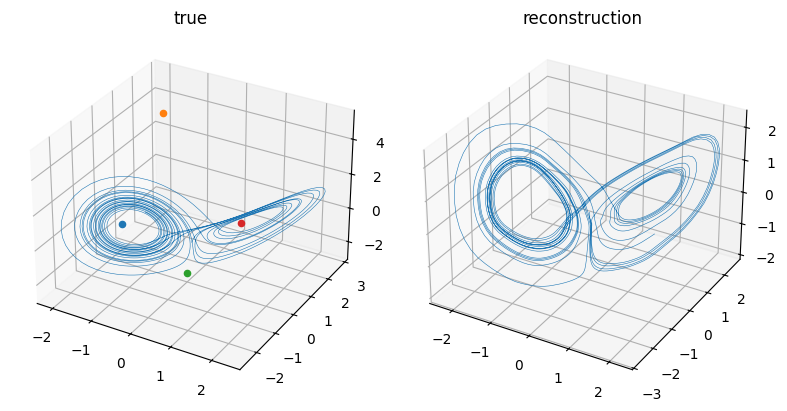

In [35]:
from neuralrnn.analysis import find_fixed_points
fps = find_fixed_points(model, backend='auto', max_order=1,
                        outer_it=30, inner_it=10)
print(f'找到 {len(fps)} 个不动点')
for p in fps:
    print('  z*=', np.round(p.z, 3), '| 稳定:', p.is_stable,
          '| max|eig|=', round(float(np.max(np.abs(p.eigenvalues))), 3))

fig = plt.figure(figsize=(8, 4))
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot(*true[:2000].T, lw=0.4); ax1.set_title('true')
for p in fps: 
    ax1.scatter(p.z[0], p.z[1], p.z[2])

ax2 = fig.add_subplot(122, projection='3d'); ax2.plot(*gen[:2000].T, lw=0.4); ax2.set_title('reconstruction')
plt.tight_layout(); plt.show()

## 5. 存读（transformers 风格）

In [36]:
model.save_pretrained('ckpt_lorenz_plrnn')   # config.json + model.safetensors
reload = AutoModel.from_pretrained('ckpt_lorenz_plrnn')
print('重载成功:', reload.__class__.__name__)

重载成功: ShallowPLRNNModel


---
**小结**：换 `Objective` 即换范式——把本教程的 `TeacherForcingObjective` 换成
`SupervisedObjective` 并改用任务数据，就是范式A（见教程 02）。